In [69]:
import openai
import pandas as pd
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Filter, FieldCondition, MatchValue, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display
from typing import Literal, Any, Annotated, List, Dict
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

In [16]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str = ""


In [8]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }

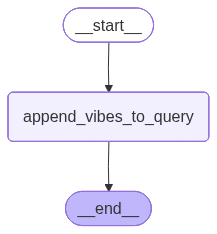

In [12]:
workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
initial_state = {
    "message": "Helo there !!",
    "vibe": "awesome day"
}

In [15]:
result = graph.invoke(initial_state)
result

{'message': 'Helo there !!',
 'answer': 'Helo there !! awesome day',
 'vibe': 'awesome day'}

### Conditional Graph

In [17]:
class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str = ""

In [18]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": state.message
    }

In [22]:
def append_vibe_1(state: State) -> dict:
    vibe = "new vibe for the day with vibe1"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [23]:
def append_vibe_2(state: State) -> dict:
    vibe = "new vibe for the day with vibe2"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [24]:
def append_vibe_3(state: State) -> dict:
    vibe = "new vibe for the day with vibe3"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [25]:
def router(state: State) -> Literal["vibe1","vibe2","vibe3"]:
    vibes = ["vibe1","vibe2","vibe3"]
    vibe_path = random.choice(vibes)
    return vibe_path

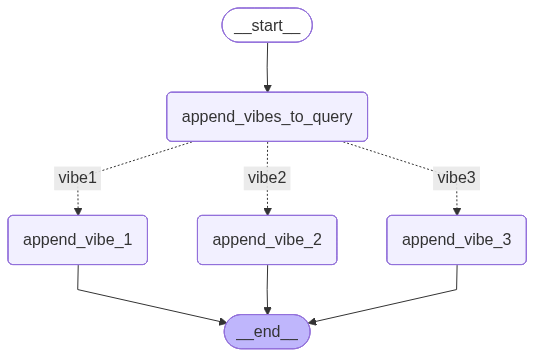

In [28]:

workflow = StateGraph(State)

workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "vibe1":"append_vibe_1",
        "vibe2":"append_vibe_2",
        "vibe3":"append_vibe_3",
    }
)

workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
initial_state = {
    "message": "Helo there !!",
    "vibe": "awesome day"
}
result = graph.invoke(initial_state)
result

{'message': 'Helo there !!',
 'answer': 'Helo there !! new vibe for the day with vibe3',
 'vibe': 'awesome day'}

### Tool calling

In [49]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

In [53]:
def dummy_tool(a: str, b: str) -> str:
    """Concatenate two strings

    Args:
        a: The first string to concatenate
        b: The second string to concatenate
    
    Returns:
        A strnig of the two strings concatenated
    """

    return f"Hello {a} and {b}"

In [54]:
from langchain_openai.chat_models.base import _use_responses_api


llm = ChatOpenAI(
    model = "gpt-5.4-mini", 
    reasoning_effort = "none",
    use_responses_api = True)

llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice = "auto"
    )

In [57]:
response = llm_with_tools.invoke("use dummy tool to concatenate 2 random words")
response

AIMessage(content=[{'arguments': '{"a":"sun","b":"flower"}', 'call_id': 'call_m1tJs4Y0ph7yRErW7WFzwkPF', 'name': 'dummy_tool', 'type': 'function_call', 'id': 'fc_0191776d2e335650006a526d34c57c81a2bb4126ce4373c2a2', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0191776d2e335650006a526d33f47c81a2831b9b2c92d5bcca', 'created_at': 1783786803.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0191776d2e335650006a526d33f47c81a2831b9b2c92d5bcca', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'sun', 'b': 'flower'}, 'id': 'call_m1tJs4Y0ph7yRErW7WFzwkPF', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 67, 'output_tokens': 23, 'total_tokens': 90, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [58]:
response.usage_metadata

{'input_tokens': 67,
 'output_tokens': 23,
 'total_tokens': 90,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [59]:
response.tool_calls

[{'name': 'dummy_tool',
  'args': {'a': 'sun', 'b': 'flower'},
  'id': 'call_m1tJs4Y0ph7yRErW7WFzwkPF',
  'type': 'tool_call'}]

## Agent Graph

In [84]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.
    
    Args:
        query: The query to append the vibe to.
        vibe: the vibe to append to the query

    Returns:
        A string with the query and vibe appended.
    """

    return f"{query} {vibe}"

In [83]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [94]:
def agent_node(state: State) -> dict:
    prompt_template = """
    You are a assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query
    - Add a random vibe to the user's query

    ## User query
    {{ query }}
    """

    jinja_template = Template(prompt_template)
    rendered_template = jinja_template.render(query = state.query)
    
    llm = ChatOpenAI(
        model = "gpt-5.4-mini", 
        reasoning_effort = "none",
        use_responses_api = True)

    llm_with_tools = llm.bind_tools(
        [append_vibes],
        tool_choice = "auto"
        )
    response = llm_with_tools.invoke(
        [
            SystemMessage(content = rendered_template)
        ]
    )

    return {
        "messages": [response]
    }

In [81]:
def tool_router(state: State) -> str:
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

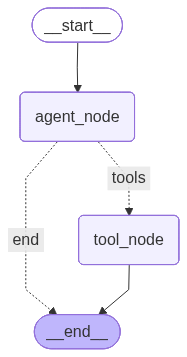

In [95]:

workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge(START, "agent_node")
workflow.add_edge("tool_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [99]:
initial_state = {"query": "do not call tools"}
result = graph.invoke(initial_state)
result

{'query': 'do not call tools',
 'messages': [AIMessage(content=[{'arguments': '{"query":"do not call tools","vibe":"with a playful, mischievous energy"}', 'call_id': 'call_9e8Km31KUmwaThyOj2mkVAfh', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0ba204e0f214cf44006a5279fd31d88192b9e94e28ba90a58e', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0ba204e0f214cf44006a5279fc54008192967666a0cc795663', 'created_at': 1783790076.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0ba204e0f214cf44006a5279fc54008192967666a0cc795663', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'do not call tools', 'vibe': 'with a playful, mischievous energy'}, 'id': 'call_9e8Km31KUmwaThyOj2mkVAfh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 150, 'output_tokens': 40, 'total_t

## Agent Graph with Loopback from Tools (ReAct Agent)

In [125]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.
    
    Args:
        query: The query to append the vibe to.
        vibe: the vibe to append to the query

    Returns:
        A string with the query and vibe appended.
    """

    return f"{query} {vibe}"

In [126]:
class State(BaseModel):
    query: str = ""
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

class FinalResponse(BaseModel):
    answer: str

In [138]:
def agent_node(state: State) -> dict:
    prompt_template = """
    You are a assistant that is generating vibes for a user.

    ## Instructions
    - You need to use the tools to add vibes to the user's query
    - Add a random vibe to the user's query
    - You must return a tool call in the first interaction
    """

    jinja_template = Template(prompt_template)
    rendered_template = jinja_template.render()
    
    llm = ChatOpenAI(
        model = "gpt-5.4-mini", 
        reasoning_effort = "none",
        use_responses_api = True)

    llm_with_tools = llm.bind_tools(
        [append_vibes, FinalResponse],
        tool_choice = "auto"
        )
    response = llm_with_tools.invoke(
        [
            SystemMessage(content = rendered_template),
            *state.messages
        ]
    )
    final_answer = False
    answer = ""
    if len(response.tool_calls)> 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")

    return {
        "messages": [response],
        "final_answer": final_answer,
        "answer": answer,
        "iteration": state.iteration + 1
    }

In [139]:
def tool_router(state: State) -> str:
    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end" 
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

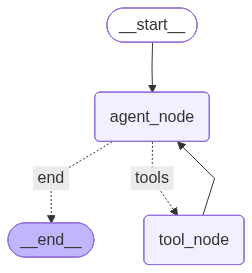

In [140]:

workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)
#------------------------
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
#------------------------
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
#------------------------
workflow.add_edge(START, "agent_node")
workflow.add_edge("tool_node", "agent_node")
#------------------------
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [141]:
initial_state = {}
result = graph.invoke(initial_state)
result

{'messages': [AIMessage(content=[{'arguments': '{"query":"User query","vibe":"with a playful, energetic, neon-lit cyberpunk vibe"}', 'call_id': 'call_wBceGDKwM1oEuP72SjLxKMXG', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_03e6669cd9861bcd006a528b8bdcf481a28d81bbf2790bba7a', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_03e6669cd9861bcd006a528b8b89fc81a2b2ff6331a9884cc8', 'created_at': 1783794571.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_03e6669cd9861bcd006a528b8b89fc81a2b2ff6331a9884cc8', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'User query', 'vibe': 'with a playful, energetic, neon-lit cyberpunk vibe'}, 'id': 'call_wBceGDKwM1oEuP72SjLxKMXG', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 166, 'output_tokens': 35, 'total_tokens': 201, 